# 0. Install NITRATES



In [1]:
# ! git clone git@github.com:Swift-BAT/NITRATES.git
# ! conda create -n nitrates_env python=3.9 -y
# ! conda activate nitrates_env
# %cd NITRATES
# ! pip install -r requirements.txt
# ! pip install -e .

# 1. Data preparation

We start with some preparatory steps. Uncomment these commands or run them on terminal, making sure you have loaded the heasoft environment

In [2]:
user_name = 'samueleronchini'
# root = f'/home/idies/workspace/Storage/{user_name}/persistent'
root = f'/Users/{user_name}/Desktop/acme_tutorials/nitrates'

Edit here trigid and trigger_time.

In [3]:
trigid = '785996578_c0'
triggertime = '2025-11-28T04:22:21.610000'

Put here your guess for the position of the external trigger

In [4]:
# Define the literature/source sky position used throughout the tutorial.
source_ra_dec = (123, 50)

## Initialize NITRATES specifying where are all the response files

In [5]:
import logging
import os
# Force Numba to use a single thread to avoid a segfault in its
# parallel JIT kernels on macOS (OpenMP + fork-safety issue).
os.environ['NUMBA_NUM_THREADS'] = '1'
from pathlib import Path
import numpy as np
from astropy.io import fits
from nitrates.lib import (
    get_conn,
    get_info_tab,
    mask_detxy,
    convert_radec2thetaphi,
    convert_theta_phi2radec,
)
from nitrates.response import RayTraces
from nitrates.models import (
    Cutoff_Plaw_Flux,
    Source_Model_InOutFoV,
    CompoundModel,
    Sig_Bkg_Model,
    get_eflux_from_model,
)
from nitrates.llh_analysis import parse_bkg_csv, LLH_webins2, NLLH_ScipyMinimize_Wjacob

logging.basicConfig(level=logging.WARNING)

# Use the explicit local response directory
resp_dir = Path(f'/Users/{user_name}/Desktop/NITRATES/tests/nitrates_resp_dir').resolve()
if not resp_dir.exists():
    raise FileNotFoundError(f'NITRATES response directory not found: {resp_dir}')

os.environ['NITRATES_RESP_DIR'] = str(resp_dir)
rt_dir = resp_dir / 'ray_traces_detapp_npy'
solid_angle_dpi_path = resp_dir / 'solid_angle_dpi.npy'

print(f"Using responses from: {resp_dir}")


Could not get the $HEADAS system variable. Please ensure that this is set and points to the HEASOFT directory.
Could not get the $CALDB system variable. Please ensure that this is set and points to the CALDB directory.
No module named 'ROOT'
Please install the Python ROOT package to be able to run the full forward modeling calculations.
16
16
[array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]), array([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]), array([55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]), array([73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]), array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104]), array([109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122]), array([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140]), array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,

/opt/anaconda3/envs/nitrates_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Here we prepare data, including detector mask file, filtered event file...

In [6]:

import os

# data_dir = f'{root}/{trigid}/data'
data_dir = f'{root}/data'

if not os.path.exists(data_dir):
    os.makedirs(data_dir)

workdir = f'{root}/{trigid}'

if not os.path.exists(workdir):
    os.makedirs(workdir)
    
def filter_data(obsid):
    command = f'python -m nitrates.data_prep.mkdb --work_dir {workdir} '
    ! echo {command}
    ! {command}
    
    # Try finding the event file
    import glob
    evt_files = glob.glob(f'{root}/data/{obsid}/bat/event/sw*bevsh*_uf.evt.gz')
    if len(evt_files) == 0:
        print(f"No event file found for {obsid}!")
        return
    evfname = evt_files[0]
    
    command = '' \
    '' \
    'python -m nitrates.data_prep.do_data_setup ' \
    f'--work_dir {workdir}' \
    f' --trig_time {triggertime}' \
    f' --evfname {evfname}' \
    f' --dmask {root}/data/{obsid}/bat/hk/sw{obsid}bdecb.hk.gz' \
    f' --att_fname {root}/data/{obsid}/auxil/sw{obsid}pat.fits.gz' \
    f' --acs_fname {root}/data/{obsid}/auxil/sw{obsid}pat.fits.gz' \
    f' --dbfname {workdir}/results.db'
    
    ! echo {command}
    ! {command}


We first get data from GUANO, using swifttools. For a complete guide to use GUANO API, see https://www.swift.psu.edu/too_api/index.php?md=Swift%20GUANO%20Example%20Notebook.ipynb

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import os
import logging
import time
from pathlib import Path
import traceback
from swifttools.swift_too import GUANO, Clock, Data

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

import warnings
warnings.filterwarnings("ignore")



def guano_query(triggertime, ext_obsid, workdir, datadir):

    if '.' not in triggertime.split('T')[1]:
        triggertime = triggertime + '.000Z'
    else:
        triggertime = triggertime + 'Z'

    logging.info(f'Using triggertime: {triggertime}')

    guano = GUANO(triggertime=triggertime, successful = False)

    logging.info(guano)

    for item in guano: # this loop is required if multiple triggers are associated with the same obsid
        logging.info(f'running {item}')

        if item.data.exposure is None:
            logging.error(f'No exposure time found for obsid {item.obsid}. Skipping this obsid.')
            exit()

        if ext_obsid is not None:
            obsid = ext_obsid
        else:
            obsid = item.obsid

        print(obsid)

        start_time_try = time.time()
        event = None
        while time.time() - start_time_try < 1800 and event is None:
            try:
                '''
                We need to remove any data or results already existing, since BatAnalysis can have problems
                '''
                # Remove directories if they exist
                obsid_dir = f"{datadir}/{obsid}"
                obsid_eventresult_dir = f"{datadir}/{obsid}_eventresult"
                if os.path.exists(obsid_dir):
                    os.system(f"rm -rf {obsid_dir}")
                if os.path.exists(obsid_eventresult_dir):
                    os.system(f"rm -rf {obsid_eventresult_dir}")


                data = Data(obsid=obsid, bat=True, outdir=datadir, clobber=True, uksdc=True)
                logging.info(data)
                filter_data(obsid)
                event = 0

            except Exception:
                logging.error(f"Failed to create Data and BatEvent for obsid {obsid}: {traceback.format_exc()}")
    
    return event


In [8]:
! pip install scikit-learn

In [9]:
guano_query(triggertime, None, workdir, data_dir)

00011439009


python -m nitrates.data_prep.mkdb --work_dir /Users/samueleronchini/Desktop/acme_tutorials/nitrates/785996578_c0


Could not get the $HEADAS system variable. Please ensure that this is set and points to the HEASOFT directory.
Could not get the $CALDB system variable. Please ensure that this is set and points to the CALDB directory.
No module named 'ROOT'
Please install the Python ROOT package to be able to run the full forward modeling calculations.
16
16
[array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]), array([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]), array([55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]), array([73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]), array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104]), array([109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122]), array([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140]), array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,

0

## Load event data and masks
We keep the exact screening used in the test suite: select good detectors, 14–500 keV photons, and a ±1000 s window around the trigger.

In [10]:
# Trigger metadata
conn = get_conn(workdir + '/results.db')
info_tab = get_info_tab(conn)
trig = info_tab['trigtimeMET'][0]

# Event data and detector mask
ev_data = fits.open(workdir + '/filter_evdata.fits')[1].data
dmask = fits.open(workdir + '/detmask.fits')[0].data
mask_vals = mask_detxy(dmask, ev_data)
bl_dmask = dmask == 0.0

# Basic time/energy cuts
t_start = trig - 50
t_end = trig + 50
bl_ev = (
    (ev_data['EVENT_FLAGS'] < 1)
    & (ev_data['ENERGY'] <= 500.0)
    & (ev_data['ENERGY'] >= 14.0)
    & (mask_vals == 0.0)
    & (ev_data['TIME'] <= t_end)
    & (ev_data['TIME'] >= t_start)
)
filtered_ev_data = ev_data[bl_ev]
print(f"Selected {len(filtered_ev_data)} events over {t_end - t_start:.1f} s")


Selected 415572 events over 100.0 s


results.db is the database file where the trigger times of all my candidates are saved

In [11]:
info_tab

,tstartMET,tstopMET,trigtimeMET,utcf,mjdref,tstartUTC,tstopUTC,trigtimeUTC
0,7.859965e+08,7.859967e+08,7.859966e+08,None,None,2025-11-28 04:21:32.236,2025-11-28 04:24:52.353,2025-11-28 04:22:21.610
1,7.859965e+08,7.859967e+08,7.859966e+08,None,None,2025-11-28 04:21:32.236,2025-11-28 04:24:52.353,2025-11-28 04:22:21.610
2,7.859965e+08,7.859967e+08,7.859966e+08,None,None,2025-11-28 04:21:32.236,2025-11-28 04:24:52.353,2025-11-28 04:22:21.610


### Let's have a quick look to the light curve

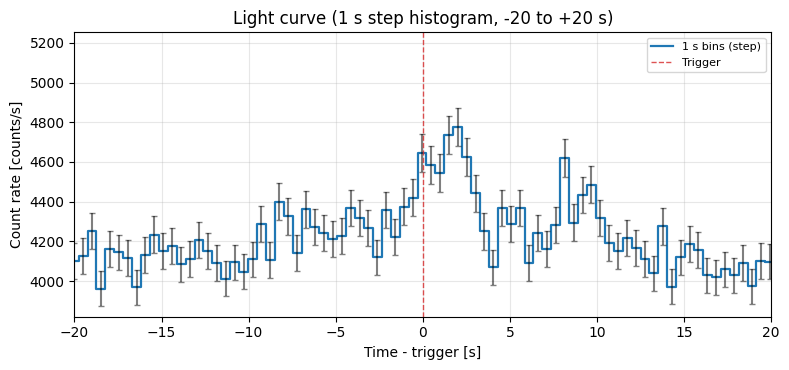

In [12]:
import matplotlib.pyplot as plt

# Light curve with 1 s bins (from the same filtered event selection)
bin_size = 0.512  # seconds

# Plot range relative to trigger: [-5, +5] s
t0_lc = trig - 30.0
t1_lc = trig + 30.0

# Use only events in that interval (filtered_ev_data is already quality/energy screened)
bl_lc = (filtered_ev_data['TIME'] >= t0_lc) & (filtered_ev_data['TIME'] <= t1_lc)
ev_lc = filtered_ev_data[bl_lc]

t_edges = np.arange(t0_lc, t1_lc + bin_size, bin_size)
counts_lc, _ = np.histogram(ev_lc['TIME'], bins=t_edges)

# Convert to count rate and Poisson errors
rate_lc = counts_lc / bin_size
rate_lc_err = np.sqrt(np.maximum(counts_lc, 1.0)) / bin_size
t_cent = 0.5 * (t_edges[:-1] + t_edges[1:])

plt.figure(figsize=(8.0, 3.8))
plt.step(t_edges[:-1] - trig, rate_lc, where='post', lw=1.6, label='1 s bins (step)')
plt.errorbar(t_cent - trig, rate_lc, yerr=rate_lc_err, fmt='none', ecolor='black', alpha=0.5, capsize=2)

plt.axvline(0.0, color='tab:red', ls='--', lw=1, alpha=0.8, label='Trigger')
plt.xlim(-20, 20)
plt.ylim(0.8 * rate_lc.max(), rate_lc.max() * 1.1)
plt.xlabel('Time - trigger [s]')
plt.ylabel('Count rate [counts/s]')
plt.title('Light curve (1 s step histogram, -20 to +20 s)')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


The GRB we are analysing is this https://gcn.nasa.gov/circulars/events/grb-210622a

## 3) Configure the spectral and spatial model
We adopt the cut-off power-law used in the paper and center the fit on the known GRB position. The `RayTraces` and response tables come from the lightweight bundle and are small enough for laptop use.

In [13]:
# Build the analysis energy bins in keV.
# `ebins0` contains the lower edge of each bin and `ebins1` the matching upper edge.
ebins0 = np.array([15.0, 24.0, 35.0, 48.0, 64.0])
ebins0 = np.append(ebins0, np.logspace(np.log10(84.0), np.log10(500.0), 5 + 1))[:-1]
ebins0 = np.round(ebins0, decimals=1)[:-1]
ebins1 = np.append(ebins0[1:], [350.0])

# Load the spacecraft attitude table and select the quaternion closest to the trigger time.
# This quaternion describes how the instrument was oriented on the sky at that moment.
attfile = fits.open(workdir + '/attitude.fits')[1].data
att_ind = np.argmin(np.abs(attfile['TIME'] - trig))
att_quat = attfile['QPARAM'][att_ind]

# Convert the source sky coordinates (RA, Dec) into instrument coordinates (theta, phi).
# The source response must be evaluated in the detector frame, not directly in RA/Dec.
theta, phi = convert_radec2thetaphi(*source_ra_dec, att_quat)

# Configure the spectral model parameters used as the initial source hypothesis.
# `A` is the normalization, `gamma` the photon index, and `Epeak` the cutoff/peak scale in keV.
flux_params = {'A': 1.0, 'gamma': 0.5, 'Epeak': 1e2}
flux_mod = Cutoff_Plaw_Flux(E0=100.0)

# Load the precomputed ray traces that encode detector shadowing across the field of view.
rt_obj = RayTraces(rt_dir)

# Build the non-imaging source model using the spectral model, energy bins, detector mask,
# ray traces, and the response tables bundled with the tutorial dataset.
sig_mod = Source_Model_InOutFoV(
    flux_mod,
    [ebins0, ebins1],
    bl_dmask,
    rt_obj,
    use_deriv=True,
    resp_tab_dname=resp_dir/'resp_tabs_ebins',
    comp_flor_resp_dname=resp_dir/'comp_flor_resps',
    hp_flor_resp_dname=resp_dir/'hp_flor_resps',
)

# Apply the instrument-frame sky position and spectral parameters to the source model.
sig_mod.set_theta_phi(theta, phi)
sig_mod.set_flux_params(flux_params)

# Print a compact summary so we can verify the selected attitude sample and derived geometry.
print(f"Pointing quaternion index: {att_ind}")
print(f"Theta/Phi (deg): {theta:.3f}, {phi:.3f}")


(0.0, 30.48, -14.117)
(0.0, 30.48, -14.117)
(45.0, 54.0)
35.59031462549889
35.59031462549889
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_45.0_phi_45.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_30.0_.fits
initing ResponseDPI, with fname
/Users/samueleronchini/Desktop/NITRATES/tests/nitrates_resp_dir/resp_tabs_ebins/drm_theta_54.0_phi_45.0_.fits
Pointing quaternion index: 175
Theta/Phi (deg): 52.335, 125.590


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


The **Source_Model_InOutFoV** function describes the *signal expected from the source*, once sky position and spectral parameters are defined. This model will be passed to the likelihood to estimate the *signal amplitude* and compare it with the *bkg model*

## 4) Background model
Operationally, `bkg_estimation.csv` is the time-dependent background model used by the LLH fit.

In practice, the background-estimation step does this:

1. Selects **off-source / background-dominated** time intervals around the trigger (outside the short on-source window).
2. Builds detector+energy count data in those intervals using the same detector mask and energy binning.
3. Fits a parametric background model (diffuse/instrument components, and optional bright point sources).
4. Solves for model parameters as a function of time (so each analysis time has a matched background state).
5. Writes the fitted parameters to `bkg_estimation.csv`.

Then `parse_bkg_csv(...)` reads that table and reconstructs the corresponding NITRATES model objects (`bkg_mod` and optional `ps_mods`) for the specific trigger time. These are combined with the source model so the LLH minimization can separate transient signal from background.

In [14]:
import os
import time
import sqlite3
import shutil
from pathlib import Path
from types import SimpleNamespace
from astropy.table import Table
import nitrates.llh_analysis.do_bkg_estimation_wPSs_mp2 as bkg_script

# bkg_estimation.csv will be written to workdir (alongside results.db)
bkg_csv_path = Path(workdir) / 'bkg_estimation.csv'
overwrite_bkg_csv = True  # set True to force regeneration
fast_bkg_only = False       # True => skip bright-source location fitting for a faster local run

# Patch script-level response paths (computed once at import time)
bkg_script.solid_angle_dpi_fname = str(resp_dir / 'solid_angle_dpi.npy')
if (resp_dir / 'bright_src_cat.fits').exists():
    bkg_script.bright_source_table_fname = str(resp_dir / 'bright_src_cat.fits')

# Build a local DB copy starting from the ACTUAL observation DB (workdir),
# then overwrite any stale absolute paths with the correct local ones.
# Data files  → workdir   (filter_evdata.fits, detmask.fits, attitude.fits)
# Response files → resp_dir (ray traces, partial-coding map)
src_db  = Path(workdir) / 'results.db'         # ← actual observation DB
local_db = Path(workdir) / 'results.localpaths.db'
shutil.copy2(src_db, local_db)

conn_local = sqlite3.connect(local_db)
cur = conn_local.cursor()

# Find Files table (case-insensitive)
table_rows = cur.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
table_map = {name.lower(): name for (name,) in table_rows}
files_table = table_map.get('files')

if files_table is not None:
    cols = [r[1] for r in cur.execute(f"PRAGMA table_info({files_table})").fetchall()]
    local_map = {
        # Data products: from the actual observation directory
        'evfname': str(Path(workdir) / 'filter_evdata.fits'),
        'detmask': str(Path(workdir) / 'detmask.fits'),
        'dmask':   str(Path(workdir) / 'detmask.fits'),
        'attfname': str(Path(workdir) / 'attitude.fits'),
        # Response products: from the shared resp_dir bundle
        'rtDir':   str(resp_dir / 'ray_traces_detapp_npy'),
        'rt_dir':  str(resp_dir / 'ray_traces_detapp_npy'),
        'pcfname': str(resp_dir / 'pc_2.img'),
    }
    for col, val in local_map.items():
        if col in cols and Path(val).exists():
            cur.execute(f"UPDATE {files_table} SET {col}=?", (val,))

conn_local.commit()
conn_local.close()

if bkg_csv_path.exists() and not overwrite_bkg_csv:
    print(f'Using existing file: {bkg_csv_path}')
else:
    args = SimpleNamespace(
        # logging / behavior flags
        preset_bkg_log_file=False,
        bkg_nopost=False,
        bkg_nopre=False,
        archive=False,
        disable_bkg_sourceloc_fit=True,
        # files/options
        dbfname=str(local_db),
        pcfname=None,
        evfname=None,
        dmask=None,
        # time windows (seconds)
        twind=20.0,
        sig_twind=20.0 * 1.024,
        bkg_dur=60.0,
        # unused but part of script CLI
        job_id=0,
        Njobs=1,
    )

    old_cwd = Path.cwd()
    t_start_bkg = time.time()

    # Optional speed-up for notebook use: ignore catalog bright sources
    _orig_get_srcs_infov = bkg_script.get_srcs_infov
    if fast_bkg_only:
        bkg_script.get_srcs_infov = lambda *a, **k: Table()

    try:
        # chdir to workdir so the script writes bkg_estimation.csv there
        os.chdir(workdir)
        bkg_script.main(args)
    finally:
        bkg_script.get_srcs_infov = _orig_get_srcs_infov
        os.chdir(old_cwd)

    dt = time.time() - t_start_bkg
    print(f'Background estimation completed in {dt:.1f} s')

print(f'bkg_estimation.csv path: {bkg_csv_path}')
print(f'Exists: {bkg_csv_path.exists()}')


-20.480000019073486
     START             STOP      
--------------- -----------------
    785996529.0   785996552.77434
785996573.25434 785996603.9743401
{'bkg_rate_0': 0.0644316720459877, 'bkg_rate_1': 0.05, 'bkg_rate_2': 0.05, 'bkg_rate_3': 0.05, 'bkg_rate_4': 0.05, 'bkg_rate_5': 0.05, 'bkg_rate_6': 0.05, 'bkg_rate_7': 0.05, 'bkg_rate_8': 0.05, 'flat_0': 0.024341512823263255, 'flat_1': 0.25, 'flat_2': 0.25, 'flat_3': 0.25, 'flat_4': 0.25, 'flat_5': 0.25, 'flat_6': 0.25, 'flat_7': 0.25, 'flat_8': 0.25}
{'bkg_rate_0': 0.0644316720459877, 'bkg_rate_1': 0.04978512727165841, 'bkg_rate_2': 0.05, 'bkg_rate_3': 0.05, 'bkg_rate_4': 0.05, 'bkg_rate_5': 0.05, 'bkg_rate_6': 0.05, 'bkg_rate_7': 0.05, 'bkg_rate_8': 0.05, 'flat_0': 0.024341512823263255, 'flat_1': 0.0, 'flat_2': 0.25, 'flat_3': 0.25, 'flat_4': 0.25, 'flat_5': 0.25, 'flat_6': 0.25, 'flat_7': 0.25, 'flat_8': 0.25}
{'bkg_rate_0': 0.0644316720459877, 'bkg_rate_1': 0.04978512727165841, 'bkg_rate_2': 0.030573630860756824, 'bkg_rate_3': 

In [15]:
# 1) Parse the background CSV and rebuild NITRATES background model objects.
#    - `bkg_df`: table of fitted background parameters vs time
#    - `bkg_mod`: diffuse/instrument background model
#    - `ps_mods`: optional persistent point-source background models
bkg_df, bkg_name, _, bkg_mod, ps_mods = parse_bkg_csv(
    bkg_csv_path,
    np.load(solid_angle_dpi_path),
    ebins0,
    ebins1,
    bl_dmask,
    rt_dir,
)

# 2) Disable derivatives for downstream stability/simplicity in this tutorial.
bkg_mod.has_deriv = False

# 3) Build a list with the diffuse background model first.
bkg_mod_list = [bkg_mod]

# 4) Append persistent point-source models (if present), also with derivatives disabled.
for ps_mod in ps_mods:
    ps_mod.has_deriv = False
    bkg_mod_list.append(ps_mod)

# 5) If we have multiple background components, combine them into a single compound model.
if len(bkg_mod_list) > 1:
    bkg_mod = CompoundModel(bkg_mod_list)

# 6) Select the background-parameter row closest in time to the trigger.
bkg_row = bkg_df.iloc[np.argmin(np.abs(trig - bkg_df['time']))]

# 7) Build the parameter dictionary expected by the active background model.
bkg_params = {pname: bkg_row[pname] for pname in bkg_mod.param_names}

# 8) Print a compact summary of loaded background components.
print(f"Background components: {[m.name for m in bkg_mod_list]}")


[]
Background components: ['Background']


We can take a look to the bkg data frame. Each row contains the parameters of the bkg at different times. In this case the bkg is estimated from t0 - 20 s up to t0 + 20s, with steps of 1 s.
In addition to diffuse bkg, also *persistent* point sources are modeled

In [16]:
bkg_df

,bkg_rate_0,bkg_rate_1,bkg_rate_2,bkg_rate_3,bkg_rate_4,bkg_rate_5,bkg_rate_6,bkg_rate_7,bkg_rate_8,flat_0,...,corr_bkg_rate_3_flat_3,corr_bkg_rate_4_flat_4,corr_bkg_rate_5_flat_5,corr_bkg_rate_6_flat_6,corr_bkg_rate_7_flat_7,corr_bkg_rate_8_flat_8,nllh,time,dt,exp
0,0.064432,0.049785,0.030574,0.027296,0.022147,0.019687,0.015181,0.010568,0.007420,0.024342,...,4.283330e-03,-0.003674,5.967951e-04,2.376471e-07,-3.870803e-03,-2.449219e-03,200850.267013,7.859966e+08,-20.480,54.49434
1,0.064370,0.049747,0.030475,0.027313,0.022096,0.019640,0.015137,0.010538,0.007398,0.046485,...,-5.052168e-04,-0.001618,-1.996133e-03,-4.490992e-08,-7.665342e-03,-3.690474e-03,202141.864834,7.859966e+08,-19.456,55.51834
2,0.064182,0.049717,0.030515,0.027295,0.022074,0.019598,0.015097,0.010528,0.007383,0.049632,...,-1.649735e-03,-0.001972,-5.498343e-03,5.271402e-08,8.120750e-03,-8.454153e-04,203518.319643,7.859966e+08,-18.432,56.54234
3,0.064147,0.049636,0.030536,0.027248,0.022010,0.019584,0.015104,0.010549,0.007394,0.076485,...,5.621949e-04,-0.001394,-6.174446e-03,-2.858828e-09,-7.023157e-03,-1.043163e-03,204928.548681,7.859966e+08,-17.408,57.56634
4,0.064075,0.049500,0.030449,0.027196,0.021943,0.019583,0.015097,0.010521,0.007373,0.066859,...,1.346743e-03,-0.002053,-6.039354e-03,4.819314e-06,-6.205688e-03,-3.612027e-03,206139.991454,7.859966e+08,-16.384,58.59034
5,0.064054,0.049440,0.030443,0.027074,0.021813,0.019530,0.014956,0.010546,0.007375,0.073034,...,-1.771784e-03,-0.001822,-2.106175e-08,-3.906720e-06,-6.792920e-03,-4.786058e-03,207303.119071,7.859966e+08,-15.360,59.61434
6,0.064075,0.049395,0.030413,0.026939,0.021726,0.019425,0.014847,0.010505,0.007344,0.029308,...,-2.389862e-03,-0.000938,-2.532449e-06,-5.052070e-03,-6.118612e-03,1.240078e-02,208329.912040,7.859966e+08,-14.336,60.63834
7,0.064094,0.049297,0.030394,0.026863,0.021636,0.019268,0.014693,0.010400,0.007297,0.022234,...,1.409311e-06,-0.002045,-2.448167e-06,1.541582e-06,-6.996008e-03,-3.027365e-06,208977.124914,7.859966e+08,-13.312,61.44000
8,0.064034,0.049245,0.030342,0.026852,0.021527,0.019132,0.014646,0.010333,0.007286,0.001839,...,4.016024e-04,-0.002247,-3.295522e-06,-5.291297e-03,-6.814587e-03,-2.427576e-08,208725.161486,7.859966e+08,-12.288,61.44000
9,0.063953,0.049148,0.030366,0.026785,0.021514,0.019124,0.014629,0.010314,0.007258,0.032946,...,6.019022e-04,-0.002201,5.019334e-08,-5.445343e-03,-4.943172e-03,-4.839627e-06,208618.122660,7.859966e+08,-11.264,61.44000


## Plotting the bkg-subtracted light curve

We use the get_rate_dpis() function and then np.nansum(rate_dpis) are needed to go from the backgroound model to the amount of total counts expected on all the detectors

### Summary of the next light-curve cell

This cell builds a **background-subtracted light curve** in the analysis energy band and shows both model and residuals.

1. Select events in the same energy range used by the background model.
2. Build time bins across the analysis interval, preserving a final partial bin if needed.
3. Compute observed count-rate per bin and Poisson errors.
4. Evaluate the background model rate at each fitted background time.
5. Interpolate background rates (and optional uncertainties) onto light-curve bin centers.
6. Compute residuals as $\mathrm{rate}_{\mathrm{obs}}-\mathrm{rate}_{\mathrm{bkg}}$ and propagate errors.
7. Plot two panels: observed vs background (top), and background-subtracted residuals (bottom).
8. Print a short run summary (energy band, time span, and last-bin width).

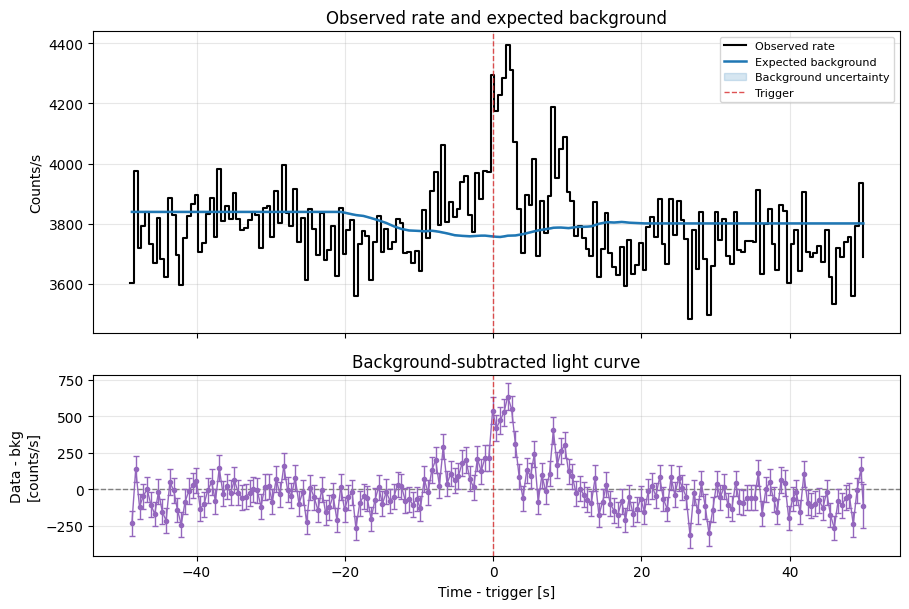

Plotted background-subtracted LC in 15.0-350.0 keV with nominal 0.512 s bins over [-50.0, +50.0] s
Manual trim: left=2, right=0
Kept bins: 194
Last bin width = 0.160 s


In [17]:
# Background-subtracted light curve over the full analysis interval.
# This cell computes: observed rate, modeled background rate, and (observed - background).

import matplotlib.pyplot as plt
import numpy as np

# 0) User controls: remove N bins at left/right edge.
trim_left_bins = 2
trim_right_bins = 0

# 1) Match the energy range actually modeled by the background.
#    This keeps data and model on exactly the same energy support.
e_lo = float(np.min(ebins0))
e_hi = float(np.max(ebins1))

ev_lc_bkg = filtered_ev_data[
    (filtered_ev_data['ENERGY'] >= e_lo) & (filtered_ev_data['ENERGY'] <= e_hi)
]

# 2) Define the nominal time bin size for the light curve (seconds).
bin_size = 0.512

# 3) Build time-bin edges across [t_start, t_end].
#    We explicitly keep the final partial bin (if any) with its true width.
t_edges = np.arange(t_start, t_end, bin_size, dtype=float)
if len(t_edges) == 0 or t_edges[0] != t_start:
    t_edges = np.r_[t_start, t_edges]
if t_edges[-1] < t_end:
    t_edges = np.r_[t_edges, t_end]

dt_bins = np.diff(t_edges)
t_cent = 0.5 * (t_edges[:-1] + t_edges[1:])

# 4) Compute observed total count rate per time bin (plus Poisson errors).
counts_obs, _ = np.histogram(ev_lc_bkg['TIME'], bins=t_edges)

# 4b) Apply manual bin trimming at edges.
if trim_left_bins < 0 or trim_right_bins < 0:
    raise ValueError('trim_left_bins and trim_right_bins must be >= 0')

n_bins_total = len(counts_obs)
if trim_left_bins + trim_right_bins >= n_bins_total:
    raise ValueError(
        f'Trimming removes all bins: n_bins={n_bins_total}, '
        f'left={trim_left_bins}, right={trim_right_bins}'
    )

i0 = int(trim_left_bins)
i1 = int(n_bins_total - trim_right_bins)

counts_obs = counts_obs[i0:i1]
dt_bins = dt_bins[i0:i1]
t_cent = t_cent[i0:i1]
t_edges = t_edges[i0:i1 + 1]

rate_obs = counts_obs / dt_bins
rate_obs_err = np.sqrt(np.maximum(counts_obs, 1.0)) / dt_bins

# 5) Evaluate expected background rate at each row/time of the fitted bkg table.
#    For each row, we construct the parameter dict, evaluate detector-plane rates,
#    and sum over detectors/energy pixels to get a total expected rate.
bkg_times = np.asarray(bkg_df['time'].values, dtype=float)
bkg_rate_rows = []
bkg_rate_err_rows = []

for _, row in bkg_df.iterrows():
    p = {pname: row[pname] for pname in bkg_mod.param_names if pname in row.index}
    rate_dpis = np.asarray(bkg_mod.get_rate_dpis(p), dtype=float)
    bkg_rate_rows.append(np.nansum(rate_dpis))

    # If the model exposes per-pixel rate uncertainties, propagate them in quadrature.
    if hasattr(bkg_mod, 'get_rate_dpis_err'):
        try:
            err_dpis = np.asarray(bkg_mod.get_rate_dpis_err(p), dtype=float)
            bkg_rate_err_rows.append(np.sqrt(np.nansum(err_dpis**2)))
        except Exception:
            bkg_rate_err_rows.append(np.nan)
    else:
        bkg_rate_err_rows.append(np.nan)

bkg_times = np.asarray(bkg_times, dtype=float)
bkg_rate_rows = np.asarray(bkg_rate_rows, dtype=float)
bkg_rate_err_rows = np.asarray(bkg_rate_err_rows, dtype=float)

# 6) Sort background points by time before interpolation.
srt = np.argsort(bkg_times)
bkg_times = bkg_times[srt]
bkg_rate_rows = bkg_rate_rows[srt]
bkg_rate_err_rows = bkg_rate_err_rows[srt]

# 7) Interpolate background model from sparse bkg-fit times to LC bin centers.
rate_bkg = np.interp(
    t_cent,
    bkg_times,
    bkg_rate_rows,
    left=bkg_rate_rows[0],
    right=bkg_rate_rows[-1],
)

if np.isfinite(bkg_rate_err_rows).any():
    ok = np.isfinite(bkg_rate_err_rows)
    rate_bkg_err = np.interp(
        t_cent,
        bkg_times[ok],
        bkg_rate_err_rows[ok],
        left=bkg_rate_err_rows[ok][0],
        right=bkg_rate_err_rows[ok][-1],
    )
else:
    rate_bkg_err = np.full_like(rate_bkg, np.nan, dtype=float)

# 8) Build background-subtracted light curve and combined uncertainty.
rate_sub = rate_obs - rate_bkg
rate_sub_err = np.sqrt(rate_obs_err**2 + np.nan_to_num(rate_bkg_err, nan=0.0)**2)

# 9) Plot two panels:
#    - Top: observed rate vs expected background
#    - Bottom: background-subtracted rate (residuals)
fig, axes = plt.subplots(
    2, 1, figsize=(9.2, 6.2), sharex=True,
    gridspec_kw={'height_ratios': [2.0, 1.2]}
)

# Top panel
axes[0].step(t_edges[:-1] - trig, rate_obs, where='post', lw=1.5, color='black', label='Observed rate')
axes[0].plot(t_cent - trig, rate_bkg, '-', lw=1.8, color='tab:blue', label='Expected background')

if np.isfinite(rate_bkg_err).any():
    ok = np.isfinite(rate_bkg_err)
    axes[0].fill_between(
        (t_cent - trig)[ok],
        (rate_bkg - rate_bkg_err)[ok],
        (rate_bkg + rate_bkg_err)[ok],
        color='tab:blue',
        alpha=0.18,
        label='Background uncertainty',
    )

axes[0].axvline(0.0, color='tab:red', ls='--', lw=1, alpha=0.8, label='Trigger')
axes[0].set_ylabel('Counts/s')
axes[0].set_title('Observed rate and expected background')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# Bottom panel
axes[1].axhline(0.0, color='gray', lw=1, ls='--')
axes[1].errorbar(
    t_cent - trig,
    rate_sub,
    yerr=rate_sub_err,
    fmt='o-',
    ms=3.0,
    lw=1.0,
    capsize=2,
    color='tab:purple',
)
axes[1].axvline(0.0, color='tab:red', ls='--', lw=1, alpha=0.8)
axes[1].set_xlabel('Time - trigger [s]')
axes[1].set_ylabel('Data - bkg\n[counts/s]')
axes[1].set_title('Background-subtracted light curve')
axes[1].grid(alpha=0.3)

# 10) Render and print a compact run summary.
plt.tight_layout()
plt.show()

print(
    f'Plotted background-subtracted LC in {e_lo:.1f}-{e_hi:.1f} keV '
    f'with nominal {bin_size:.3f} s bins over [{t_start - trig:+.1f}, {t_end - trig:+.1f}] s'
)
print(f'Manual trim: left={trim_left_bins}, right={trim_right_bins}')
print(f'Kept bins: {len(counts_obs)}')
print(f'Last bin width = {dt_bins[-1]:.3f} s')

## Likelihood object
In this step we build the full object chain that turns event data + models into an optimizable likelihood.

### What each function/class is doing operationally

1. `sig_pars = dict(flux_params)` and `sig_pars.update({'A': 1.0, 'theta': theta, 'phi': phi})`
   - Creates the signal parameter dictionary used by the source model.
   - Includes spectral shape (`gamma`, `Epeak`), normalization (`A`), and sky location (`theta`, `phi`).

2. `Sig_Bkg_Model(bl_dmask, sig_mod, bkg_mod, use_deriv=True)`
   - Combines **signal model** and **background model** into one forward model.
   - Internally this model can return expected detector/energy rates and counts for any parameter set.
   - With `use_deriv=True`, it exposes derivatives/Jacobians that speed up minimization.

3. `sig_bkg_mod.set_bkg_params(bkg_params)`
   - Loads the background-fit parameters (from `bkg_estimation.csv`) into the combined model.
   - This fixes the baseline expected count-rate surface from background components.

4. `sig_bkg_mod.set_sig_params(sig_pars)`
   - Loads the signal parameters into the same combined model.
   - At this stage the model can evaluate total expected counts = background + signal.

5. `LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)`
   - Builds the Poisson likelihood engine over detector and energy bins.
   - Uses the filtered event list plus detector mask and the exact analysis energy binning.
   - `has_err=True` keeps support for model uncertainties where available.

6. `sig_llh_obj.set_model(sig_bkg_mod)`
   - Attaches the combined (signal+background) model to the likelihood object.
   - From here, `sig_llh_obj` can compute log-probability/NLLH for any parameter values.

7. `NLLH_ScipyMinimize_Wjacob('')` + `set_llh(sig_llh_obj)`
   - Creates the numerical optimizer wrapper and links it to the LLH object.
   - The optimizer uses SciPy minimization and, when available, analytic Jacobians.

8. `sig_miner.set_fixed_params(['A'], fixed=False)`
   - Marks amplitude `A` as a free parameter for optimization in the next scan cells.
   - Other parameters stay fixed in this tutorial step (shape and sky location held constant).

So after this cell, the notebook is fully configured to evaluate and minimize the NLLH in each time window, producing best-fit `A` and then $\sqrt{TS}$.

In [18]:
sig_pars = dict(flux_params)
sig_pars.update({'A': 1.0, 'theta': theta, 'phi': phi})

sig_bkg_mod = Sig_Bkg_Model(bl_dmask, sig_mod, bkg_mod, use_deriv=True)
sig_bkg_mod.set_bkg_params(bkg_params)
sig_bkg_mod.set_sig_params(sig_pars)

sig_llh_obj = LLH_webins2(filtered_ev_data, ebins0, ebins1, bl_dmask, has_err=True)
sig_llh_obj.set_model(sig_bkg_mod)

sig_miner = NLLH_ScipyMinimize_Wjacob('')
sig_miner.set_llh(sig_llh_obj)
sig_miner.set_fixed_params(['A'], fixed=False)


## Scan a few on-source windows


In [19]:
AMPLITUDE_FLOOR = 1e-10  # small positive floor used to approximate zero-signal without risking log(0)
def evaluate_window(t0, duration):
    t1 = t0 + duration
    sig_llh_obj.set_time(t0, t1)
    bf_vals, nllh, _ = sig_miner.minimize()
    best_vals = np.atleast_1d(bf_vals[0])  # scipy wrapper returns [array([...])] so pull first element
    amp = float(best_vals[0])
    bkg_nllh = -sig_llh_obj.get_logprob({'A': AMPLITUDE_FLOOR})
    sqrtTS = np.sqrt(2.0 * (bkg_nllh - nllh[0]))
    return {'t0': t0, 't1': t1, 'duration': duration, 'amplitude': amp, 'sqrtTS': sqrtTS}

windows = [0.512, 1.024, 2.048]
results = [evaluate_window(trig - 0.5 * dur, dur) for dur in windows]
results


[{'t0': 785996578.11834,
  't1': 785996578.63034,
  'duration': 0.512,
  'amplitude': 0.05451667537115488,
  'sqrtTS': 7.754393562066208},
 {'t0': 785996577.8623401,
  't1': 785996578.8863401,
  'duration': 1.024,
  'amplitude': 0.04965598802665707,
  'sqrtTS': 10.044585593175738},
 {'t0': 785996577.35034,
  't1': 785996579.39834,
  'duration': 2.048,
  'amplitude': 0.04432499972390377,
  'sqrtTS': 12.774939294959957}]

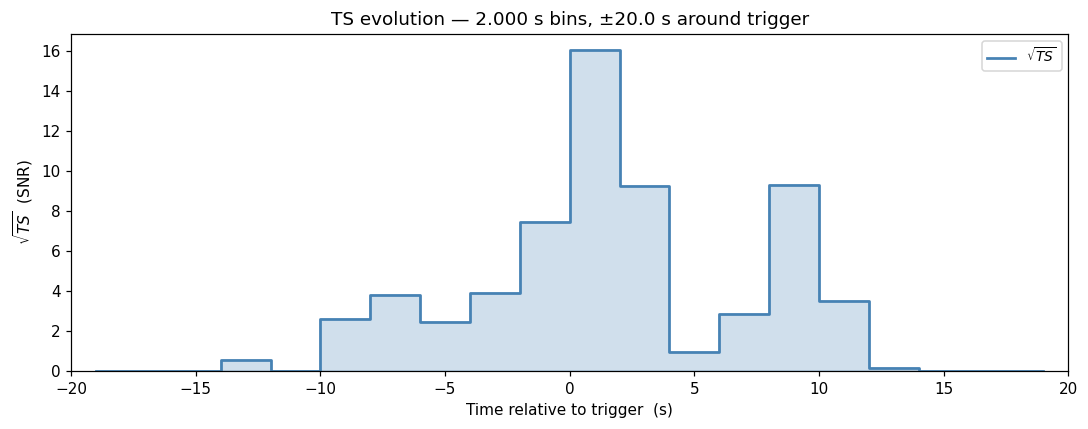


Peak bin:  t_mid = +1.000 s,  √TS = 16.04


In [20]:

# ── TS evolution: 10 bins of 1.024 s before and after T₀ ────────────────────
# Evaluates 20 contiguous 1.024-s windows centred around the trigger time and
# plots how √TS evolves across the burst epoch.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

SCAN_DUR  = 2          # window duration (s)
N_BINS    = 10             # bins on each side of T₀
t_starts  = [trig + (i - N_BINS) * SCAN_DUR for i in range(2 * N_BINS)]

ts_rows   = [evaluate_window(t, SCAN_DUR) for t in t_starts]
ts_tmid   = np.array([r['t0'] + SCAN_DUR / 2.0 - float(trig) for r in ts_rows])
ts_snr    = np.array([r['sqrtTS'] for r in ts_rows])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4), dpi=110)

ax.step(ts_tmid, ts_snr, where='mid', color='steelblue', lw=1.8, label=r'$\sqrt{TS}$')
ax.fill_between(ts_tmid, 0, ts_snr, step='mid', alpha=0.25, color='steelblue')

ax.set_xlabel('Time relative to trigger  (s)')
ax.set_ylabel(r'$\sqrt{TS}$  (SNR)')
ax.set_title(f'TS evolution — {SCAN_DUR:.3f} s bins, ±{N_BINS * SCAN_DUR:.1f} s around trigger')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(ts_tmid[0] - SCAN_DUR / 2, ts_tmid[-1] + SCAN_DUR / 2)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f"\nPeak bin:  t_mid = {ts_tmid[ts_snr.argmax()]:+.3f} s,  √TS = {ts_snr.max():.2f}")


## Do the full time seeds search and split rates 

In [21]:
# Run the split-detector rates scan through a local wrapper that patches nitrates.config.
# Time seeds are generated with the standard NITRATES full-rates step.

import glob
import os
import subprocess
import sys
import textwrap
import time
import numpy as np
import pandas as pd

workdir_path = Path(workdir)

# ------------------------------------------------------------------
# 1) Standard NITRATES step: generate time_seeds.csv via do_full_rates
#    Equivalent shell command:
#    python -m nitrates.analysis_seeds.do_full_rates --api_token "$api_token" > full_rates.out 2>&1
# ------------------------------------------------------------------
time_seeds_path = workdir_path / 'time_seeds.csv'
full_rates_log = workdir_path / 'full_rates.out'

cmd_full_rates = [
    sys.executable,
    '-m', 'nitrates.analysis_seeds.do_full_rates',
    '--dbfname', 'results.localpaths.db',
]

print('Running full-rates seed step:', ' '.join(cmd_full_rates))

with open(full_rates_log, 'w') as fout:
    proc_full = subprocess.run(
        cmd_full_rates,
        cwd=str(workdir_path),
        stdout=fout,
        stderr=subprocess.STDOUT,
        text=True,
    )

print(f"do_full_rates exit code: {proc_full.returncode}")
if full_rates_log.exists():
    tail = full_rates_log.read_text(errors='ignore')[-3000:]
    if tail.strip():
        print("── full_rates.out (tail) ──\n", tail)

if proc_full.returncode != 0:
    raise RuntimeError('do_full_rates failed; inspect full_rates.out in workdir.')

if not time_seeds_path.exists():
    raise FileNotFoundError(f'do_full_rates finished but {time_seeds_path.name} was not found in workdir.')

# do_full_rates writes 'NONE' when no seed passes threshold.
try:
    time_seeds_df = pd.read_csv(time_seeds_path)
except Exception:
    raw = time_seeds_path.read_text(errors='ignore').strip()
    if raw == 'NONE':
        raise RuntimeError('do_full_rates completed but found 0 time seeds (time_seeds.csv == NONE).')
    raise

print(f"Loaded {time_seeds_path.name} with {len(time_seeds_df)} windows (from do_full_rates)")

# ------------------------------------------------------------------
# 2) Locate response tables required by do_rates_mle_InOutFoV2
# ------------------------------------------------------------------
rates_resp_in_dir = resp_dir / 'rates_resps'
rates_resp_out_dir = resp_dir / 'rates_resps_outFoV2'
if not (rates_resp_in_dir.exists() and rates_resp_out_dir.exists()):
    raise FileNotFoundError(
        'Missing rates response tables: expected both rates_resps/ and rates_resps_outFoV2/ inside resp_dir.'
    )

# ------------------------------------------------------------------
# 3) Write a thin wrapper that patches nitrates.config before import
# ------------------------------------------------------------------
pcfname_repr = repr(str(resp_dir / 'pc_2.img')) if (resp_dir / 'pc_2.img').exists() else 'None'
wrapper_code = textwrap.dedent(f"""\
    from types import SimpleNamespace

    import nitrates.config as cfg

    cfg.NITRATES_RESP_DIR = {str(resp_dir)!r}
    cfg.rates_resp_dir = {str(rates_resp_in_dir)!r}
    cfg.rates_resp_out_dir = {str(rates_resp_out_dir)!r}
    cfg.rt_dir = {str(resp_dir / 'ray_traces_detapp_npy')!r}
    cfg.solid_angle_dpi_fname = {str(resp_dir / 'solid_angle_dpi.npy')!r}

    import nitrates.analysis_seeds.do_rates_mle_InOutFoV2 as script

    script.rates_resp_dir = cfg.rates_resp_dir
    script.rates_resp_out_dir = cfg.rates_resp_out_dir
    script.rt_dir = cfg.rt_dir
    script.solid_angle_dpi_fname = cfg.solid_angle_dpi_fname

    args = SimpleNamespace(
        dbfname='results.localpaths.db',
        bkg_fname='bkg_estimation.csv',
        time_seed_fname='time_seeds.csv',
        pcfname={pcfname_repr},
        pix_fname='good_pix2scan.npy',
        min_pc=0.1,
        Njobs=32,
        job_id=0,
    )

    script.main(args)
""")

wrapper_path = resp_dir / '_rates_mle_wrapper.py'
wrapper_path.write_text(wrapper_code)

# ------------------------------------------------------------------
# 4) Execute wrapper from workdir and collect outputs
# ------------------------------------------------------------------
cmd = [sys.executable, str(wrapper_path)]
print('Running wrapper:', ' '.join(cmd))
t0_rates = time.time()
proc = subprocess.run(cmd, cwd=str(workdir_path), capture_output=True, text=True)
elapsed = time.time() - t0_rates

print(f"Exit code: {proc.returncode} ({elapsed:.1f} s)")
if proc.stdout.strip():
    print("── stdout ──\n", proc.stdout[-3000:])
if proc.stderr.strip():
    print("── stderr ──\n", proc.stderr[-2000:])
if proc.returncode != 0:
    raise RuntimeError('Wrapper execution failed; inspect stdout/stderr above.')

# Load the CSVs generated by the rates scan (written to workdir).
csv_files = sorted(
    glob.glob(str(workdir_path / 'rates_llh_res_*.csv'))
    + glob.glob(str(workdir_path / 'rates_llh_out_res_*.csv'))
)
if not csv_files:
    raise FileNotFoundError('Wrapper finished but no rates_llh output CSVs were found.')

temporal_seeds = pd.concat([pd.read_csv(fname) for fname in csv_files], ignore_index=True)
temporal_seeds['time_rel'] = temporal_seeds['time'] - float(trig)

ts_col = 'TS' if 'TS' in temporal_seeds.columns else 'sqrtTS'
display_cols = [c for c in ['time_rel', 'dur', 'A', ts_col, 'nllh', 'bkg_nllh'] if c in temporal_seeds.columns]
top_seeds = temporal_seeds.nlargest(min(10, len(temporal_seeds)), ts_col)[display_cols]
print(f"Loaded {len(temporal_seeds)} rows from {len(csv_files)} CSV(s)")
print(f"Top temporal seeds (ranked by {ts_col}):")
print(top_seeds.to_string(index=False))


Running full-rates seed step: /opt/anaconda3/envs/nitrates_env/bin/python -m nitrates.analysis_seeds.do_full_rates --dbfname results.localpaths.db
do_full_rates exit code: 0
── full_rates.out (tail) ──
 8,  9, 10, 11, 12, 13, 14]), array([19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]), array([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]), array([55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]), array([73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]), array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104]), array([109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122]), array([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140]), array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158]), array([163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
       176]), array([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,
      

In [22]:
temporal_seeds

,dur,imx,imy,ndets,solid_angle,timeID,time,A,Epeak,gamma,nllh,bkg_nllh,TS,time_rel
0,0.256,0.98,0.32,8972,9132.761152,-76160256,7.859966e+08,0.001488,1000.000000,0.913523,63.973514,67.116794,2.507301,-7.616
1,0.256,0.98,0.32,8972,9132.761152,-76800256,7.859966e+08,0.001533,1000.000000,0.483716,57.364011,60.725660,2.592932,-7.680
2,0.256,0.98,0.32,8972,9132.761152,-67840256,7.859966e+08,0.001768,1000.000000,0.049708,71.406370,77.481699,3.485779,-6.784
3,0.256,0.98,0.32,8972,9132.761152,-67200256,7.859966e+08,0.001764,1000.000000,0.647709,67.247029,71.662262,2.971610,-6.720
4,0.256,0.98,0.32,8972,9132.761152,-16000256,7.859966e+08,0.005600,231.120968,-0.100000,59.671189,65.213000,3.329208,-1.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2720,8.192,0.14,-0.96,271,260.395709,-40968192,7.859966e+08,0.006798,248.361742,0.302754,90.453570,247.074832,17.698659,-4.096
2721,8.192,0.14,-0.96,271,260.395709,-20488192,7.859966e+08,0.006478,250.368056,0.106363,89.044893,218.697560,16.102960,-2.048
2722,8.192,0.14,-0.96,271,260.395709,8192,7.859966e+08,0.004922,268.945397,0.316925,82.013944,181.767855,14.124724,0.000
2723,16.384,0.14,-0.96,271,260.395709,-409616384,7.859966e+08,0.005804,230.874040,-0.049825,89.008077,242.325910,17.511016,-4.096


## Waterfall plot

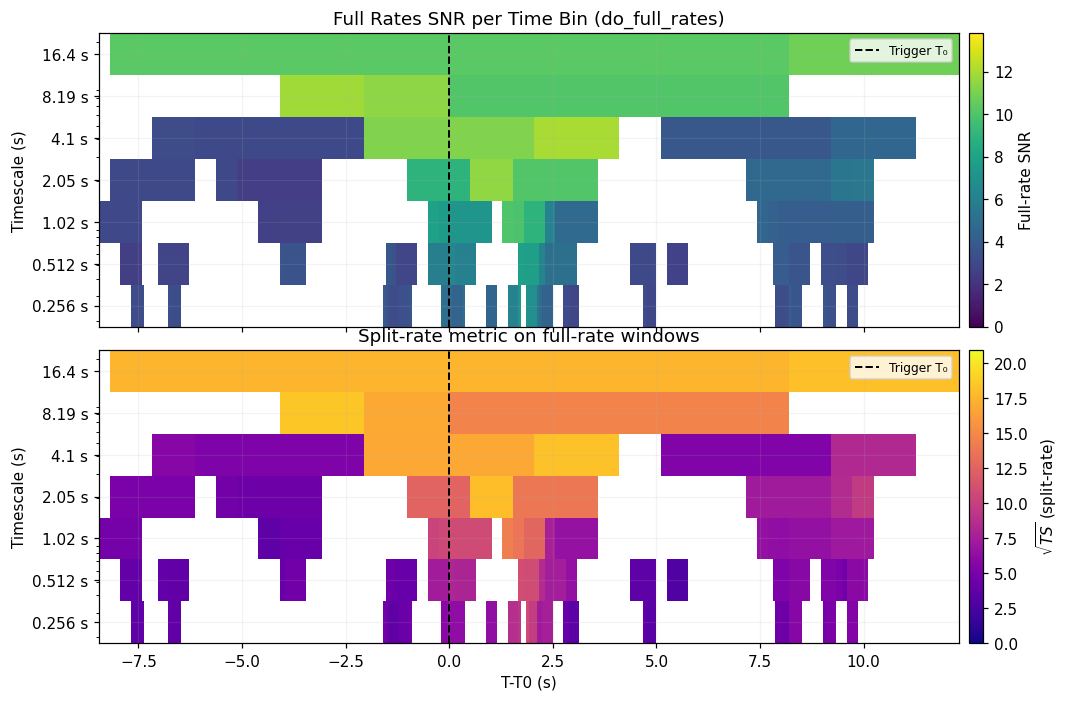

Full-rate seeds plotted: 109
Best split-rate overlay: t0=-1.024 s, dur=4.096 s, sqrtTS=20.962


In [28]:
# Waterfall plots aligned with NITRATES products used by the GUANO report:
# - Top: Full-rate SNR from time_seeds.csv (do_full_rates output).
# - Bottom: Split-rate significance mapped by timeID (rates_llh_res_* outputs).

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

workdir_path = Path(workdir)

# ------------------------------------------------------------------
# 1) Load full-rate seeds exactly as produced by do_full_rates
# ------------------------------------------------------------------
if 'time_seeds_df' in globals() and isinstance(time_seeds_df, pd.DataFrame):
    seeds_df = time_seeds_df.copy()
else:
    seeds_df = pd.read_csv(workdir_path / 'time_seeds.csv')

required_cols = {'duration', 'snr'}
if not required_cols.issubset(seeds_df.columns):
    raise KeyError(f'time_seeds.csv must contain columns {required_cols}, found {set(seeds_df.columns)}')

if 'dt' in seeds_df.columns:
    # dt is the start time of each window relative to trigger in seconds
    seeds_df['t0_rel'] = seeds_df['dt'].astype(float)
elif 'time' in seeds_df.columns:
    seeds_df['t0_rel'] = seeds_df['time'].astype(float) - float(trig)
else:
    raise KeyError("time_seeds.csv needs either 'dt' or 'time' column")

seeds_df['dur'] = seeds_df['duration'].astype(float)
seeds_df['snr'] = seeds_df['snr'].astype(float)

# ------------------------------------------------------------------
# 2) Attach split-rate metric by timeID (if available)
# ------------------------------------------------------------------
split_df = None
if 'temporal_seeds' in globals() and isinstance(temporal_seeds, pd.DataFrame):
    split_df = temporal_seeds.copy()
else:
    csv_files = sorted(glob.glob(str(workdir_path / 'rates_llh_res_*.csv')))
    if csv_files:
        split_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

if split_df is not None and ('timeID' in split_df.columns):
    split_ts_col = 'TS' if 'TS' in split_df.columns else ('sqrtTS' if 'sqrtTS' in split_df.columns else None)
    if split_ts_col is not None:
        if split_ts_col == 'TS':
            split_df['sqrtTS_plot'] = np.clip(split_df['TS'].astype(float), 0, None)
        else:
            split_df['sqrtTS_plot'] = split_df['sqrtTS'].astype(float)
        # keep best split-rate value per time bin
        split_best = split_df.groupby('timeID', as_index=False)['sqrtTS_plot'].max()
        seeds_df = seeds_df.merge(split_best, on='timeID', how='left')
    else:
        seeds_df['sqrtTS_plot'] = np.nan
else:
    seeds_df['sqrtTS_plot'] = np.nan

# ------------------------------------------------------------------
# 3) Build duration bands (log-spaced y-axis geometry)
# ------------------------------------------------------------------
uniq_durs = np.array(sorted(seeds_df['dur'].dropna().unique()), dtype=float)
if len(uniq_durs) < 2:
    raise RuntimeError('Need at least two distinct durations to build waterfall plot.')

y_edges = np.empty(len(uniq_durs) + 1, dtype=float)
y_edges[1:-1] = np.sqrt(uniq_durs[:-1] * uniq_durs[1:])
y_edges[0] = uniq_durs[0] ** 2 / y_edges[1]
y_edges[-1] = uniq_durs[-1] ** 2 / y_edges[-2]
dur_to_i = {d: i for i, d in enumerate(uniq_durs)}

# ------------------------------------------------------------------
# 4) Draw two-panel waterfall
# ------------------------------------------------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(12, 7.2), dpi=110, sharex=True, sharey=True,
    gridspec_kw={'height_ratios': [1.0, 1.0], 'hspace': 0.08}
)

# Top panel: Full-rate SNR from do_full_rates
patches_top, colors_top = [], []
for _, r in seeds_df.iterrows():
    d = float(r['dur'])
    i = dur_to_i.get(d, None)
    if i is None:
        continue
    t0 = float(r['t0_rel'])
    rect = Rectangle((t0, y_edges[i]), d, y_edges[i + 1] - y_edges[i])
    patches_top.append(rect)
    colors_top.append(float(r['snr']))

pc_top = PatchCollection(patches_top, cmap='viridis', edgecolors='none')
pc_top.set_array(np.asarray(colors_top, dtype=float))
pc_top.set_clim(0, max(10.0, float(np.nanmax(colors_top))))
ax_top.add_collection(pc_top)
plt.colorbar(pc_top, ax=ax_top, label='Full-rate SNR', pad=0.01)
ax_top.axvline(0.0, color='black', lw=1.3, ls='--', label='Trigger T₀')
ax_top.set_yscale('log')
ax_top.set_yticks(uniq_durs)
ax_top.set_yticklabels([f'{d:.3g} s' for d in uniq_durs])
ax_top.set_ylabel('Timescale (s)')
ax_top.set_title('Full Rates SNR per Time Bin (do_full_rates)')
ax_top.grid(alpha=0.15)
ax_top.legend(loc='upper right', fontsize=8)

# Bottom panel: Split-rate √TS mapped on same windows (when available)
patches_bottom, colors_bottom = [], []
for _, r in seeds_df.iterrows():
    v = r['sqrtTS_plot']
    if not np.isfinite(v):
        continue
    d = float(r['dur'])
    i = dur_to_i.get(d, None)
    if i is None:
        continue
    t0 = float(r['t0_rel'])
    rect = Rectangle((t0, y_edges[i]), d, y_edges[i + 1] - y_edges[i])
    patches_bottom.append(rect)
    colors_bottom.append(float(v))

if patches_bottom:
    pc_bottom = PatchCollection(patches_bottom, cmap='plasma', edgecolors='none')
    pc_bottom.set_array(np.asarray(colors_bottom, dtype=float))
    pc_bottom.set_clim(0, max(4.0, float(np.nanmax(colors_bottom))))
    ax_bottom.add_collection(pc_bottom)
    plt.colorbar(pc_bottom, ax=ax_bottom, label=r'$\sqrt{TS}$ (split-rate)', pad=0.01)

ax_bottom.axvline(0.0, color='black', lw=1.3, ls='--', label='Trigger T₀')
ax_bottom.set_yscale('log')
ax_bottom.set_yticks(uniq_durs)
ax_bottom.set_yticklabels([f'{d:.3g} s' for d in uniq_durs])
ax_bottom.set_xlabel('T-T0 (s)')
ax_bottom.set_ylabel('Timescale (s)')
ax_bottom.set_title('Split-rate metric on full-rate windows')
ax_bottom.grid(alpha=0.15)
ax_bottom.legend(loc='upper right', fontsize=8)

x_min = float(np.nanmin(seeds_df['t0_rel']))
x_max = float(np.nanmax(seeds_df['t0_rel'] + seeds_df['dur']))
ax_bottom.set_xlim(x_min, x_max)
ax_bottom.set_ylim(y_edges[0], y_edges[-1])

plt.tight_layout()
plt.show()

print(f"Full-rate seeds plotted: {len(seeds_df)}")
if np.isfinite(seeds_df['sqrtTS_plot']).any():
    best_idx = int(np.nanargmax(seeds_df['sqrtTS_plot'].values))
    b = seeds_df.iloc[best_idx]
    print(f"Best split-rate overlay: t0={b['t0_rel']:+.3f} s, dur={b['dur']:.3f} s, sqrtTS={b['sqrtTS_plot']:.3f}")
else:
    print('No split-rate overlay available (missing timeID/TS in rates outputs).')

In [24]:
best = max(results, key=lambda row: row['sqrtTS'])
ra_best, dec_best = convert_theta_phi2radec(theta, phi, att_quat)
fluence_band = (15.0, 150.0)
fluence = get_eflux_from_model(flux_mod, {'A': best['amplitude'], 'gamma': flux_params['gamma'], 'Epeak': flux_params['Epeak']}, *fluence_band)

print(f"Best window: {best['duration']:.3f}s starting at {best['t0'] - trig:+.3f} s relative to trigger")
print(f"sqrtTS: {best['sqrtTS']:.2f}")
print(f"Amplitude A: {best['amplitude']:.3e}")
print(f"Sky position (RA, Dec): ({ra_best:.3f}, {dec_best:.3f})")
print(f"Energy flux {fluence_band[0]:.0f}-{fluence_band[1]:.0f} keV: {fluence:.3e} erg/cm^2/s")


Best window: 2.048s starting at -1.024 s relative to trigger
sqrtTS: 12.77
Amplitude A: 4.432e-02
Sky position (RA, Dec): (123.000, 50.000)
Energy flux 15-150 keV: 2.458e-07 erg/cm^2/s


## Exploring the spectral parameter space

### Summary of the next cell (best-time-bin spectral scan)

This cell selects the strongest temporal seed and then profiles the spectral parameters in that interval.

1. Picks the best time window from the temporal-seed table (highest TS or $\sqrt{TS}$).
2. Sets that interval in the likelihood object and computes the background-only reference NLLH.
3. Scans a grid in $(\gamma, E_{\rm peak})$, profiling over amplitude $A$ at each grid point.
4. Stores per-grid-point results (`A_best`, NLLH, TS, $\sqrt{TS}$).
5. Identifies the best-fit spectral point and prints a compact summary.
6. Plots two maps: profiled $\sqrt{TS}$ and $\Delta$NLLH in spectral space.
7. Saves the best temporal/spectral solution into dictionaries for downstream cells, then restores the prior model state.

In [ ]:
# ------------------------------------------------------------------
# Spectral grid scan: profile over A at fixed (gamma, Epeak)
# ------------------------------------------------------------------
gamma_grid = np.linspace(-0.5, 1.1, 20)
epeak_grid = np.logspace(np.log10(30.0), np.log10(1500.0), 20)


=== Best temporal bin from waterfall ===
Start time rel. trigger: -1.024 s
Stop  time rel. trigger: +3.072 s
Duration: 4.096 s
TS: 20.962

=== Best spectral parameters in that temporal bin ===
A      = 3.552e-02
gamma  = -0.079
Epeak  = 155.77 keV
sqrtTS = 20.814


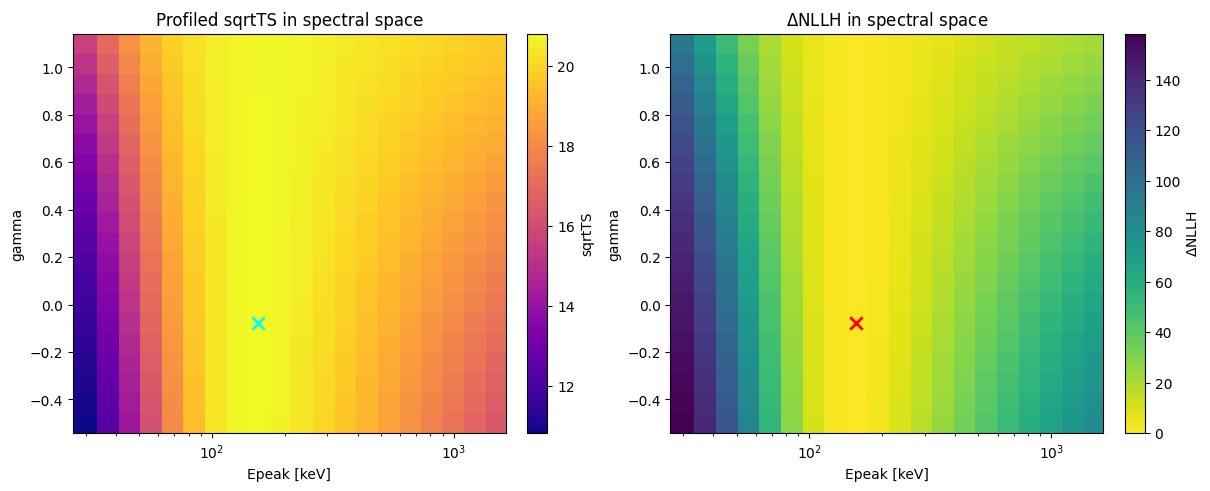

In [ ]:
# Estimate the best temporal bin from the waterfall products, then estimate
# the best spectral parameters (gamma, Epeak) in that bin by profiling over A.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) Pick the best temporal bin from the waterfall/temporal seed table
# ------------------------------------------------------------------
ts_col = 'TS' if 'TS' in temporal_seeds.columns else 'sqrtTS'
dur_col = 'dur' if 'dur' in temporal_seeds.columns else 'duration'

seed_best = temporal_seeds.loc[temporal_seeds[ts_col].astype(float).idxmax()]

dur_spec = float(seed_best[dur_col])

if 'time' in seed_best.index:
    t0_spec = float(seed_best['time'])
elif 'time_rel' in seed_best.index:
    t0_spec = float(trig) + float(seed_best['time_rel'])
elif 'timeID' in seed_best.index:
    seed_row = time_seeds_df.loc[time_seeds_df['timeID'] == int(seed_best['timeID'])].iloc[0]
    t0_spec = float(seed_row['time'])
    if dur_col == 'duration':
        dur_spec = float(seed_row['duration'])
else:
    raise KeyError("Could not determine the start time of the best temporal bin.")
t1_spec = t0_spec + dur_spec

print('=== Best temporal bin from waterfall ===')
print(f"Start time rel. trigger: {t0_spec - float(trig):+.3f} s")
print(f"Stop  time rel. trigger: {t1_spec - float(trig):+.3f} s")
print(f"Duration: {dur_spec:.3f} s")
print(f"{ts_col}: {float(seed_best[ts_col]):.3f}")

# ------------------------------------------------------------------
# 2) Build the background-only NLLH in that time window
# ------------------------------------------------------------------
sig_llh_obj.set_time(t0_spec, t1_spec)

restore_flux_params = {
    'A': float(best['amplitude']),
    'gamma': float(flux_params['gamma']),
    'Epeak': float(flux_params['Epeak']),
}
restore_sig_params = {
    'A': float(best['amplitude']),
    'gamma': float(flux_params['gamma']),
    'Epeak': float(flux_params['Epeak']),
    'theta': float(theta),
    'phi': float(phi),
}

bkg_nllh_spec = -float(sig_llh_obj.get_logprob({'A': AMPLITUDE_FLOOR}))

# Ensure only A is free during the spectral scan
sig_miner.set_fixed_params(['A'], fixed=False)

scan_rows = []

for gamma_i in gamma_grid:
    for epeak_i in epeak_grid:
        try:
            trial_flux_params = {
                'A': 1.0,
                'gamma': float(gamma_i),
                'Epeak': float(epeak_i),
            }
            trial_sig_params = {
                'A': 1.0,
                'gamma': float(gamma_i),
                'Epeak': float(epeak_i),
                'theta': float(theta),
                'phi': float(phi),
            }

            sig_mod.set_flux_params(trial_flux_params)
            sig_bkg_mod.set_sig_params(trial_sig_params)

            bf_vals, nllh_vals, _ = sig_miner.minimize()
            amp_best_i = float(np.atleast_1d(bf_vals[0])[0])
            nllh_best_i = float(nllh_vals[0])

            if ts_col == 'TS':
                ts_like_i = 2.0 * (bkg_nllh_spec - nllh_best_i)
                sqrt_ts_i = np.sqrt(max(ts_like_i, 0.0))
            else:
                sqrt_ts_i = np.sqrt(max(2.0 * (bkg_nllh_spec - nllh_best_i), 0.0))
                ts_like_i = sqrt_ts_i**2

            scan_rows.append({
                'gamma': float(gamma_i),
                'Epeak': float(epeak_i),
                'A_best': amp_best_i,
                'nllh': nllh_best_i,
                'TS': ts_like_i,
                'sqrtTS': sqrt_ts_i,
            })

        except Exception:
            scan_rows.append({
                'gamma': float(gamma_i),
                'Epeak': float(epeak_i),
                'A_best': np.nan,
                'nllh': np.nan,
                'TS': np.nan,
                'sqrtTS': np.nan,
            })

spec_scan_df = pd.DataFrame(scan_rows).dropna(subset=['nllh']).reset_index(drop=True)
if len(spec_scan_df) == 0:
    raise RuntimeError('No valid spectral grid points were evaluated.')

best_spec = spec_scan_df.loc[spec_scan_df['nllh'].idxmin()]

print('\n=== Best spectral parameters in that temporal bin ===')
print(f"A      = {best_spec['A_best']:.3e}")
print(f"gamma  = {best_spec['gamma']:.3f}")
print(f"Epeak  = {best_spec['Epeak']:.2f} keV")
print(f"sqrtTS = {best_spec['sqrtTS']:.3f}")

# ------------------------------------------------------------------
# Make a 2D likelihood/TS plot in spectral space
# ------------------------------------------------------------------
pivot_ts = spec_scan_df.pivot(index='gamma', columns='Epeak', values='sqrtTS')
pivot_nllh = spec_scan_df.pivot(index='gamma', columns='Epeak', values='nllh')

E_grid = pivot_ts.columns.values.astype(float)
G_grid = pivot_ts.index.values.astype(float)
Z_ts = pivot_ts.values
Z_nllh = pivot_nllh.values

dllh = Z_nllh - np.nanmin(Z_nllh)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.8), constrained_layout=True)

pcm1 = ax1.pcolormesh(E_grid, G_grid, Z_ts, shading='auto', cmap='plasma')
ax1.scatter(best_spec['Epeak'], best_spec['gamma'], marker='x', s=80, color='cyan', linewidths=2)
ax1.set_xscale('log')
ax1.set_xlabel('Epeak [keV]')
ax1.set_ylabel('gamma')
ax1.set_title('Profiled sqrtTS in spectral space')
fig.colorbar(pcm1, ax=ax1, label='sqrtTS')

pcm2 = ax2.pcolormesh(E_grid, G_grid, dllh, shading='auto', cmap='viridis_r')
ax2.scatter(best_spec['Epeak'], best_spec['gamma'], marker='x', s=80, color='red', linewidths=2)
ax2.set_xscale('log')
ax2.set_xlabel('Epeak [keV]')
ax2.set_ylabel('gamma')
ax2.set_title(r'$\Delta$NLLH in spectral space')
fig.colorbar(pcm2, ax=ax2, label=r'$\Delta$NLLH')

plt.show()

# ------------------------------------------------------------------
# Store convenient summary variables for later cells
# ------------------------------------------------------------------
best_temporal_bin_from_waterfall = {
    't0': t0_spec,
    't1': t1_spec,
    'duration': dur_spec,
    ts_col: float(seed_best[ts_col]),
}

best_spectral_from_waterfall_bin = {
    'A': float(best_spec['A_best']),
    'gamma': float(best_spec['gamma']),
    'Epeak': float(best_spec['Epeak']),
    'sqrtTS': float(best_spec['sqrtTS']),
    't0': t0_spec,
    't1': t1_spec,
    'duration': dur_spec,
}

# Restore notebook state
sig_mod.set_flux_params(restore_flux_params)
sig_bkg_mod.set_sig_params(restore_sig_params)

Note: compare the values of TS and spectral params with the one at the bottom of https://guano.swift.psu.edu/trigger_report?id=646018383

### Background-subtracted spectrum vs user-chosen signal model

The next cell compares the observed spectrum in the best time window with a user-defined source model after removing the estimated background. Operationally, it does the following:

1. Selects the time interval with the largest detection significance found in the previous scan.
2. Builds the observed spectrum on the native likelihood energy bins used by the NITRATES background model.
3. Evaluates the background model in those same bins and propagates its uncertainty when available.
4. Subtracts the expected background from the observed spectrum to obtain the net data spectrum.
5. Replaces the source spectral shape with the user-chosen parameters $A$, $\gamma$, and $E_{\rm peak}$ while keeping the same sky position.
6. Forward-folds that signal model through the detector response and converts it to a net count-rate density.
7. Plots the background-subtracted data together with the raw user-defined signal model for a direct visual comparison.
8. Prints the integrated net data rate and the integrated model signal rate, then restores the original source-model parameters.

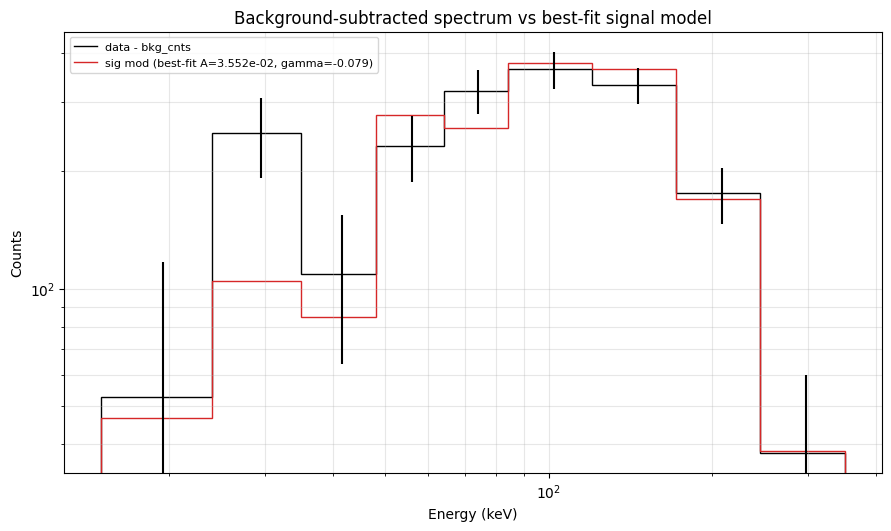

,E0_keV,E1_keV,data_counts,bkg_counts,data_minus_bkg,sig_counts_bestfit,data_err_sqrtN
0,15.0,24.0,4117.0,4064.001778,52.998222,46.631818,64.163853
1,24.0,35.0,3376.0,3126.466515,249.533485,104.348589,58.103356
2,35.0,48.0,2025.0,1915.936339,109.063661,84.757665,45.000000
3,48.0,64.0,1943.0,1711.334420,231.665580,278.315195,44.079474
4,64.0,84.0,1680.0,1359.076443,320.923557,257.983712,40.987803
5,84.0,120.0,1563.0,1199.139419,363.860581,377.911617,39.534795
6,120.0,171.5,1238.0,906.866656,331.133344,364.629667,35.185224
7,171.5,245.0,821.0,645.734193,175.265807,169.798027,28.653098
8,245.0,350.0,497.0,459.000592,37.999408,38.532515,22.293497


In [29]:
# Compare the background-subtracted data spectrum with the best-fit signal model.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Best-fit parameters from the previous cell (spectral scan on best temporal bin)
if 'best_spectral_from_waterfall_bin' not in globals():
    raise NameError("best_spectral_from_waterfall_bin not found. Run the previous spectral-scan cell first.")

fit_A = float(best_spectral_from_waterfall_bin['A'])
fit_gamma = float(best_spectral_from_waterfall_bin['gamma'])
fit_Epeak = float(best_spectral_from_waterfall_bin['Epeak'])
t0_fit = float(best_spectral_from_waterfall_bin['t0'])
t1_fit = float(best_spectral_from_waterfall_bin['t1'])

sig_pars_best = {
    'A': fit_A,
    'Epeak': fit_Epeak,
    'gamma': fit_gamma,
    'theta': float(theta),
    'phi': float(phi),
}

# Set time window in likelihood object
sig_llh_obj.set_time(t0_fit, t1_fit)

# Data counts
cnts_ebin = np.sum(sig_llh_obj.data_dpis, axis=1)
cnts_ebin_err = np.sqrt(np.maximum(cnts_ebin, 1.0))

# Background counts
bkg_dpis = np.reshape(sig_bkg_mod.bkg_cnt_dpis, sig_llh_obj.data_dpis.shape)
bkg_cnts = np.sum(bkg_dpis, axis=1)

# Signal counts from best-fit
sig_mod.set_flux_params(sig_pars_best)
sig_bkg_mod.set_sig_params(sig_pars_best)
sig_dpis_best = np.reshape(sig_bkg_mod.sig_cnt_dpis, sig_llh_obj.data_dpis.shape)
sig_cnts_best = np.sum(sig_dpis_best, axis=1)

edges = np.append(ebins0, [ebins1[-1]])
centers = 0.5 * (ebins0 + ebins1)
data_minus_bkg = cnts_ebin - bkg_cnts

# Plot 1: reference style (data-bkg vs sig model using best-fit parameters)
fig, ax = plt.subplots(figsize=(8.8, 5.2), constrained_layout=True)
ax.stairs(data_minus_bkg, edges, label='data - bkg_cnts', color='black')
ax.stairs(sig_cnts_best, edges, label=f'sig mod (best-fit A={fit_A:.3e}, gamma={fit_gamma:.3f})', color='tab:red')
ax.errorbar(centers, data_minus_bkg, yerr=cnts_ebin_err, fmt='none', ecolor='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.set_ylabel('Counts')
ax.set_xlabel('Energy (keV)')
ax.set_title('Background-subtracted spectrum vs best-fit signal model')
ax.grid(alpha=0.3, which='both')
plt.show()

spec_df = pd.DataFrame({
    'E0_keV': ebins0,
    'E1_keV': ebins1,
    'data_counts': cnts_ebin,
    'bkg_counts': bkg_cnts,
    'data_minus_bkg': data_minus_bkg,
    'sig_counts_bestfit': sig_cnts_best,
    'data_err_sqrtN': cnts_ebin_err,
})

display(spec_df)

### Forward-folded `emcee` spectral fit in the best time window



The next cell performs a lightweight Bayesian fit using the same forward-folded NITRATES signal model and Poisson likelihood used by the official analysis.



Operationally, it does the following:



1. Selects the best on-source time window found above.

2. Reuses the existing NITRATES source, background, and likelihood objects.

3. Samples the spectral parameters $A$, $\gamma$, and $E_{\rm peak}$ with `emcee` directly through the forward-folded detector-space likelihood.

4. Keeps the NITRATES normalization convention, so the posterior on $A$ is directly comparable to the official pipeline output.

5. Builds a posterior predictive band for the forward-folded signal model and compares it with the background-subtracted spectrum for visualization.

6. Stores the posterior samples and summary values for the following diagnostic cells.


In [30]:
# Forward-folded emcee spectral fit in the best time window.
import numpy as np
import matplotlib.pyplot as plt
import emcee

# Set time window in likelihood object
sig_llh_obj.set_time(t0_fit, t1_fit)

# Parameterization sampled by emcee: [log10(A), gamma, log10(Epeak)]
logA_bounds = (-8.0, 1.5)
gamma_bounds = (-2.5, 3.0)
logEp_bounds = (np.log10(20.0), np.log10(3000.0))

def unpack(theta_vec):
    logA, gamma_i, logEp = theta_vec
    return 10.0**logA, gamma_i, 10.0**logEp

def log_prior(theta_vec):
    logA, gamma_i, logEp = theta_vec
    if not (logA_bounds[0] < logA < logA_bounds[1]):
        return -np.inf
    if not (gamma_bounds[0] < gamma_i < gamma_bounds[1]):
        return -np.inf
    if not (logEp_bounds[0] < logEp < logEp_bounds[1]):
        return -np.inf
    return 0.0

def log_probability(theta_vec):
    lp = log_prior(theta_vec)
    if not np.isfinite(lp):
        return -np.inf

    A_i, gamma_i, Epeak_i = unpack(theta_vec)

    trial_flux_params = {
        'A': 1.0,
        'gamma': float(gamma_i),
        'Epeak': float(Epeak_i),
    }
    trial_sig_params = {
        'A': 1.0,
        'gamma': float(gamma_i),
        'Epeak': float(Epeak_i),
        'theta': float(theta),
        'phi': float(phi),
    }

    try:
        sig_mod.set_flux_params(trial_flux_params)
        sig_bkg_mod.set_sig_params(trial_sig_params)
        llh_val = float(sig_llh_obj.get_logprob({'A': float(A_i)}))
    except Exception:
        return -np.inf

    if not np.isfinite(llh_val):
        return -np.inf
    return lp + llh_val

# Initialize walkers around the best-fit values found above.
A0 = max(float(fit_A), 1e-6)
g0 = float(fit_gamma)
Ep0 = max(float(fit_Epeak), 50.0)
p0_center = np.array([np.log10(A0), g0, np.log10(Ep0)], dtype=float)

nwalkers = 12
ndim = 3
nburn = 40
nsteps = 500
rng = np.random.default_rng(12345)

scatter = np.array([0.08, 0.08, 0.08], dtype=float)
p0 = p0_center + scatter * rng.standard_normal((nwalkers, ndim))

p0[:, 0] = np.clip(p0[:, 0], logA_bounds[0] + 1e-4, logA_bounds[1] - 1e-4)
p0[:, 1] = np.clip(p0[:, 1], gamma_bounds[0] + 1e-4, gamma_bounds[1] - 1e-4)
p0[:, 2] = np.clip(p0[:, 2], logEp_bounds[0] + 1e-4, logEp_bounds[1] - 1e-4)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

state = sampler.run_mcmc(p0, nburn, progress=True)
sampler.reset()
sampler.run_mcmc(state, nsteps, progress=True)

flat_samples = sampler.get_chain(flat=True)
log_prob_samples = sampler.get_log_prob(flat=True)

q16, q50, q84 = np.percentile(flat_samples, [16, 50, 84], axis=0)
A_med, gamma_med, Epeak_med = unpack(q50)
A_lo, gamma_lo, Epeak_lo = unpack(q16)
A_hi, gamma_hi, Epeak_hi = unpack(q84)

best_fit_emcee_params = {
    'A': float(A_med),
    'gamma': float(gamma_med),
    'Epeak': float(Epeak_med),
    't0': float(t0_fit),
    't1': float(t1_fit),
    'duration': float(t1_fit - t0_fit),
}

# Posterior predictive band in native bins (Counts)
nsamp_plot = min(200, len(flat_samples))
draw_idx = rng.choice(len(flat_samples), size=nsamp_plot, replace=False)

sig_cnts_draws = []
for idx in draw_idx:
    A_i, gamma_i, Epeak_i = unpack(flat_samples[idx])
    trial_sig_params = {
        'A': float(A_i),
        'gamma': float(gamma_i),
        'Epeak': float(Epeak_i),
        'theta': float(theta),
        'phi': float(phi),
    }

    sig_mod.set_flux_params(trial_sig_params)
    sig_bkg_mod.set_sig_params(trial_sig_params)
    sig_dpis = np.reshape(sig_bkg_mod.sig_cnt_dpis, sig_llh_obj.data_dpis.shape)
    sig_cnts_draws.append(np.sum(sig_dpis, axis=1))

sig_cnts_draws = np.asarray(sig_cnts_draws, dtype=float)
sig_cnts_q16, sig_cnts_q50, sig_cnts_q84 = np.percentile(
    sig_cnts_draws, [16, 50, 84], axis=0
)

100%|██████████| 500/500 [02:24<00:00,  3.46it/s]


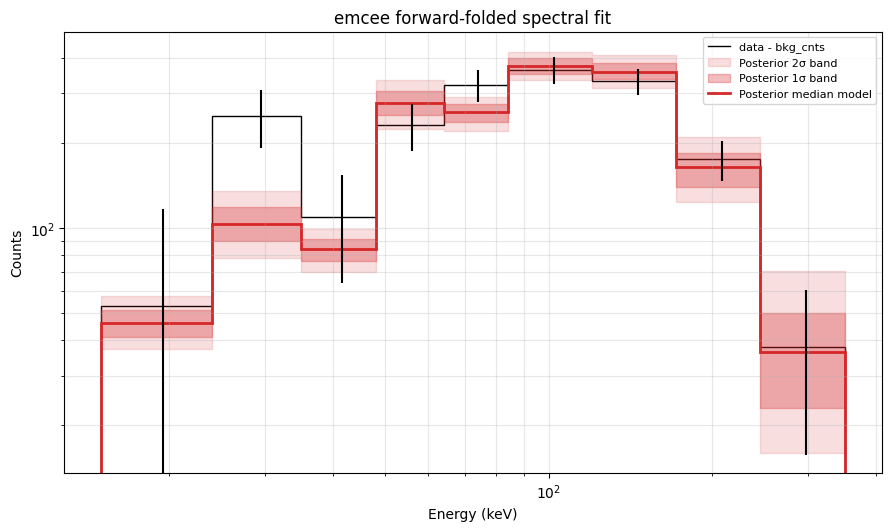

=== emcee posterior summary ===
Time window: -1.024 to +3.072 s relative to trigger
A      = 3.409e-02 (+4.423e-02/-1.563e-02)
gamma  = 0.050 (+0.739/-1.102)
Epeak  = 151.71 (+21.81/-13.75) keV
Mean acceptance fraction = 0.574
Posterior sample count   = 6000


In [31]:
# Plot 1: reference style (data-bkg vs sig model posterior)
fig, ax = plt.subplots(figsize=(8.8, 5.2), constrained_layout=True)

ax.stairs(data_minus_bkg, edges, label='data - bkg_cnts', color='black')

# 1σ (68%) and 2σ (95%) posterior bands from forward-folded draws
q2p5, q16, q50, q84, q97p5 = np.percentile(sig_cnts_draws, [2.5, 16, 50, 84, 97.5], axis=0)

y_2s_low_ext = np.append(q2p5, q2p5[-1])
y_2s_high_ext = np.append(q97p5, q97p5[-1])
y_1s_low_ext = np.append(q16, q16[-1])
y_1s_high_ext = np.append(q84, q84[-1])

ax.fill_between(
    edges, y_2s_low_ext, y_2s_high_ext,
    step='post', color='tab:red', alpha=0.15, label='Posterior 2σ band'
)
ax.fill_between(
    edges, y_1s_low_ext, y_1s_high_ext,
    step='post', color='tab:red', alpha=0.30, label='Posterior 1σ band'
)
ax.stairs(q50, edges, label='Posterior median model', color='tab:red', lw=2.0)

ax.errorbar(centers, data_minus_bkg, yerr=cnts_ebin_err, fmt='none', ecolor='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.set_ylabel('Counts')
ax.set_xlabel('Energy (keV)')
ax.set_title('emcee forward-folded spectral fit')
ax.grid(alpha=0.3, which='both')
plt.show()

print("=== emcee posterior summary ===")
print(f"Time window: {t0_fit - trig:+.3f} to {t1_fit - trig:+.3f} s relative to trigger")
print(f"A      = {A_med:.3e} (+{A_hi - A_med:.3e}/-{A_med - A_lo:.3e})")
print(f"gamma  = {gamma_med:.3f} (+{gamma_hi - gamma_med:.3f}/-{gamma_med - gamma_lo:.3f})")
print(f"Epeak  = {Epeak_med:.2f} (+{Epeak_hi - Epeak_med:.2f}/-{Epeak_med - Epeak_lo:.2f}) keV")
print(f"Mean acceptance fraction = {np.mean(sampler.acceptance_fraction):.3f}")
print(f"Posterior sample count   = {len(flat_samples)}")

# Restore notebook state
sig_mod.set_flux_params(sig_pars_best)
sig_bkg_mod.set_sig_params(sig_pars_best)

Posterior summaries (log-parameters):
  $\log_{10} A$: -1.4673 (+0.3612/-0.2664)
  $\gamma$: 0.0496 (+0.7387/-1.1020)
  $\log_{10}(E_{\rm peak}/{\rm keV})$: 2.1810 (+0.0583/-0.0413)

Posterior summaries (physical units):
  A: 3.409e-02 (+4.423e-02/-1.563e-02)
  Epeak [keV]: 151.710 (+21.811/-13.747)
corner package not available, using fallback pair-plot. Error: No module named 'corner'


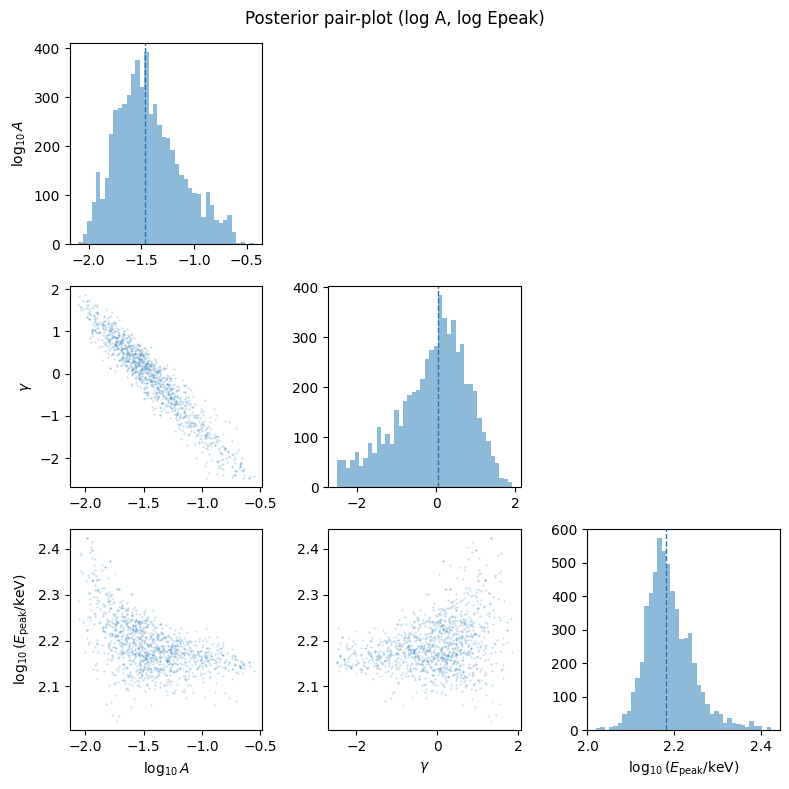

In [32]:
# Corner plot of posterior parameters from emcee + printed summaries
samples_corner = flat_samples  # columns: [log10(A), gamma, log10(Epeak)]
labels = [r"$\log_{10} A$", r"$\gamma$", r"$\log_{10}(E_{\rm peak}/{\rm keV})$"]

# ---- Numeric summaries (median and 68% CI) ----
q16, q50, q84 = np.percentile(samples_corner, [16, 50, 84], axis=0)

print("Posterior summaries (log-parameters):")
for i, lab in enumerate(labels):
    lo = q50[i] - q16[i]
    hi = q84[i] - q50[i]
    print(f"  {lab}: {q50[i]:.4f} (+{hi:.4f}/-{lo:.4f})")

# Also print physical units for A and Epeak
A_samp = 10.0 ** samples_corner[:, 0]
Ep_samp = 10.0 ** samples_corner[:, 2]
A16, A50, A84 = np.percentile(A_samp, [16, 50, 84])
Ep16, Ep50, Ep84 = np.percentile(Ep_samp, [16, 50, 84])

print("\nPosterior summaries (physical units):")
print(f"  A: {A50:.3e} (+{A84 - A50:.3e}/-{A50 - A16:.3e})")
print(f"  Epeak [keV]: {Ep50:.3f} (+{Ep84 - Ep50:.3f}/-{Ep50 - Ep16:.3f})")

# ---- Plot ----
try:
    import corner

    fig = corner.corner(
        samples_corner,
        labels=labels,
        truths=[q50[0], q50[1], q50[2]],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
        title_kwargs={"fontsize": 10},
    )
    fig.suptitle("Posterior corner plot (log A, log Epeak)", y=1.02)

except Exception as e:
    print("corner package not available, using fallback pair-plot. Error:", e)

    pars = [samples_corner[:, 0], samples_corner[:, 1], samples_corner[:, 2]]
    npar = len(pars)
    fig, axes = plt.subplots(npar, npar, figsize=(8, 8))
    for i in range(npar):
        for j in range(npar):
            ax = axes[i, j]
            if i == j:
                ax.hist(pars[i], bins=40, histtype='stepfilled', alpha=0.5)
                ax.axvline(np.median(pars[i]), ls='--', lw=1)
            elif i > j:
                ax.plot(pars[j][::5], pars[i][::5], '.', ms=1, alpha=0.25)
            else:
                ax.axis('off')

            if i == npar - 1:
                ax.set_xlabel(labels[j])
            if j == 0:
                ax.set_ylabel(labels[i])

    fig.suptitle("Posterior pair-plot (log A, log Epeak)")
    plt.tight_layout()
    plt.show()

In [33]:
# Derive flux confidence intervals from posterior spectral parameters:
# - Energy flux in 15–350 keV [erg/cm^2/s]
# - Photon flux in 10–1000 keV [ph/cm^2/s]

ELO_E, EHI_E = 15.0, 350.0
ELO_P, EHI_P = 10.0, 1000.0

def _eval_dnde(model, E, pars):
    """Best-effort evaluator for dN/dE [ph cm^-2 s^-1 keV^-1] from NITRATES flux models."""
    candidates = ["spec", "get_dnde", "dnde", "flux"]
    for name in candidates:
        if hasattr(model, name):
            fn = getattr(model, name)
            for call in (
                lambda: fn(E, pars),
                lambda: fn(E, **pars),
                lambda: fn(pars, E),
            ):
                try:
                    y = np.asarray(call(), dtype=float)
                    if y.shape == np.shape(E) and np.all(np.isfinite(y)):
                        return y
                except Exception:
                    pass

    # Fallback: callable model
    for call in (
        lambda: model(E, pars),
        lambda: model(E, **pars),
        lambda: model(pars, E),
    ):
        try:
            y = np.asarray(call(), dtype=float)
            if y.shape == np.shape(E) and np.all(np.isfinite(y)):
                return y
        except Exception:
            pass

    raise RuntimeError("Could not evaluate dN/dE from flux model. Check model API.")

def get_pflux_from_model(model, pars, elo, ehi, nE=2048):
    E = np.logspace(np.log10(elo), np.log10(ehi), int(nE))
    dnde = _eval_dnde(model, E, pars)
    return float(np.trapz(dnde, E))  # ph/cm^2/s

if 'flat_samples' in globals() and len(flat_samples) > 0:
    # flat_samples columns: [log10(A), gamma, log10(Epeak)]
    if 'unpack' in globals():
        phys_params = np.array([unpack(th) for th in flat_samples], dtype=float)  # [A, gamma, Epeak]
    else:
        phys_params = np.column_stack([
            10.0 ** flat_samples[:, 0],
            flat_samples[:, 1],
            10.0 ** flat_samples[:, 2],
        ])

    eflux_samples = np.array([
        get_eflux_from_model(
            flux_mod,
            {'A': float(Ai), 'gamma': float(gi), 'Epeak': float(Epi)},
            ELO_E, EHI_E
        )
        for Ai, gi, Epi in phys_params
    ], dtype=float)

    pflux_samples = np.array([
        get_pflux_from_model(
            flux_mod,
            {'A': float(Ai), 'gamma': float(gi), 'Epeak': float(Epi)},
            ELO_P, EHI_P
        )
        for Ai, gi, Epi in phys_params
    ], dtype=float)

    e16, e50, e84 = np.percentile(eflux_samples, [16, 50, 84])
    e05, e95 = np.percentile(eflux_samples, [5, 95])

    p16, p50, p84 = np.percentile(pflux_samples, [16, 50, 84])
    p05, p95 = np.percentile(pflux_samples, [5, 95])

    flux_ci_15_350 = {
        'median': e50, 'q16': e16, 'q84': e84, 'q05': e05, 'q95': e95
    }
    pflux_ci_10_1000 = {
        'median': p50, 'q16': p16, 'q84': p84, 'q05': p05, 'q95': p95
    }

    print(f"Energy flux {ELO_E:.0f}-{EHI_E:.0f} keV (posterior):")
    print(f"  median = {e50:.3e} erg/cm^2/s")
    print(f"  68% CI = [{e16:.3e}, {e84:.3e}]")
    print(f"  90% CI = [{e05:.3e}, {e95:.3e}]")

    print(f"\nPhoton flux {ELO_P:.0f}-{EHI_P:.0f} keV (posterior):")
    print(f"  median = {p50:.3e} ph/cm^2/s")
    print(f"  68% CI = [{p16:.3e}, {p84:.3e}]")
    print(f"  90% CI = [{p05:.3e}, {p95:.3e}]")
else:
    raise RuntimeError("No posterior samples found (expected `flat_samples`). Run the emcee cell first.")

Energy flux 15-350 keV (posterior):
  median = 3.024e-07 erg/cm^2/s
  68% CI = [2.721e-07, 3.348e-07]
  90% CI = [2.547e-07, 3.631e-07]

Photon flux 10-1000 keV (posterior):
  median = 2.367e+00 ph/cm^2/s
  68% CI = [1.718e+00, 3.353e+00]
  90% CI = [1.502e+00, 4.403e+00]


In [34]:
# Compute sqrt(TS) at the current best-fit spectral parameters and time window

# Pick best-fit source parameters already produced in previous cells
if 'best_fit_emcee_params' in globals():
    A_bf = float(best_fit_emcee_params['A'])
    gamma_bf = float(best_fit_emcee_params['gamma'])
    Epeak_bf = float(best_fit_emcee_params['Epeak'])
    t0_bf = float(best_fit_emcee_params['t0'])
    t1_bf = float(best_fit_emcee_params['t1'])
elif 'best_spectral_from_waterfall_bin' in globals():
    A_bf = float(best_spectral_from_waterfall_bin['A'])
    gamma_bf = float(best_spectral_from_waterfall_bin['gamma'])
    Epeak_bf = float(best_spectral_from_waterfall_bin['Epeak'])
    t0_bf = float(best_spectral_from_waterfall_bin['t0'])
    t1_bf = float(best_spectral_from_waterfall_bin['t1'])
else:
    A_bf = float(fit_A)
    gamma_bf = float(fit_gamma)
    Epeak_bf = float(fit_Epeak)
    t0_bf = float(t0_fit)
    t1_bf = float(t1_fit)

# Configure model in that window
sig_llh_obj.set_time(t0_bf, t1_bf)
sig_mod.set_flux_params({'A': 1.0, 'gamma': gamma_bf, 'Epeak': Epeak_bf})
sig_bkg_mod.set_sig_params({
    'A': 1.0,
    'gamma': gamma_bf,
    'Epeak': Epeak_bf,
    'theta': float(theta),
    'phi': float(phi),
})

# Log-likelihoods: best-fit signal vs background-only
llh_sig = float(sig_llh_obj.get_logprob({'A': max(A_bf, AMPLITUDE_FLOOR)}))
llh_bkg = float(sig_llh_obj.get_logprob({'A': AMPLITUDE_FLOOR}))

TS_best = max(2.0 * (llh_sig - llh_bkg), 0.0)
sqrtTS_best = np.sqrt(TS_best)

print(f"Best-fit window: [{t0_bf - trig:+.3f}, {t1_bf - trig:+.3f}] s")
print(f"A={A_bf:.3e}, gamma={gamma_bf:.3f}, Epeak={Epeak_bf:.2f} keV")
print(f"TS={TS_best:.6f}, sqrtTS={sqrtTS_best:.6f}")

Best-fit window: [-1.024, +3.072] s
A=3.409e-02, gamma=0.050, Epeak=151.71 keV
TS=433.265688, sqrtTS=20.815035
